# Regression

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "student_lifestyle_performance_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sehaj1104/student-lifestyle-and-academic-performance-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for mostudent_lifestyle_performance_dataset.csvre information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_131806/3133178035.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [32]:
df.head()

,Age,Branch,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Diet_Type,Attendance_Percentage,Stress_Level_1_to_10,Residence,Internal_Marks,CGPA
0,23,ECE,4.14,6.84,9.23,2.67,Non-Veg,81.24,4.93,Hosteller,65.86,7.52
1,20,Civil,5.97,5.52,3.09,15.61,Veg,90.55,6.96,Day Scholar,62.52,7.21
2,24,Electrical,3.19,3.39,5.02,2.52,Veg,69.40,7.38,Hosteller,40.11,4.84
3,21,CSE,4.77,6.44,9.21,0.00,Non-Veg,80.79,5.84,Day Scholar,61.25,6.74
4,23,Civil,5.42,6.54,4.76,9.93,Veg,82.63,6.67,Day Scholar,64.54,7.77


In [33]:
df.dtypes

Age                        int64
Branch                       str
Study_Hours_per_Day      float64
Sleep_Hours              float64
Screen_Time_Hours        float64
Gym_Hours_per_Week       float64
Diet_Type                    str
Attendance_Percentage    float64
Stress_Level_1_to_10     float64
Residence                    str
Internal_Marks           float64
CGPA                     float64
dtype: object

## Preprocessiong

In [34]:
df.isna().sum()

Age                      0
Branch                   0
Study_Hours_per_Day      0
Sleep_Hours              0
Screen_Time_Hours        0
Gym_Hours_per_Week       0
Diet_Type                0
Attendance_Percentage    0
Stress_Level_1_to_10     0
Residence                0
Internal_Marks           0
CGPA                     0
dtype: int64

In [35]:
df.drop(columns=['Age'], inplace=True)

In [36]:
df.columns

Index(['Branch', 'Study_Hours_per_Day', 'Sleep_Hours', 'Screen_Time_Hours',
       'Gym_Hours_per_Week', 'Diet_Type', 'Attendance_Percentage',
       'Stress_Level_1_to_10', 'Residence', 'Internal_Marks', 'CGPA'],
      dtype='str')

In [37]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

/tmp/ipykernel_131806/3445425799.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object', 'category']).columns


In [38]:
categorical_columns

Index(['Branch', 'Diet_Type', 'Residence'], dtype='str')

In [39]:
for col in categorical_columns:
   print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'Branch': <StringArray>
['ECE', 'Civil', 'Electrical', 'CSE', 'Mechanical', 'IT']
Length: 6, dtype: str
Unique values in 'Diet_Type': <StringArray>
['Non-Veg', 'Veg']
Length: 2, dtype: str
Unique values in 'Residence': <StringArray>
['Hosteller', 'Day Scholar']
Length: 2, dtype: str


In [40]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(drop='first', sparse_output=False)

encoded = ohe.fit_transform(df[categorical_columns])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(categorical_columns))

# gabungkan dengan fitur numerik
df_final = pd.concat([df.drop(columns=categorical_columns), encoded_df], axis=1)

In [41]:
df_final.head()

,Study_Hours_per_Day,Sleep_Hours,Screen_Time_Hours,Gym_Hours_per_Week,Attendance_Percentage,Stress_Level_1_to_10,Internal_Marks,CGPA,Branch_Civil,Branch_ECE,Branch_Electrical,Branch_IT,Branch_Mechanical,Diet_Type_Veg,Residence_Hosteller
0,4.14,6.84,9.23,2.67,81.24,4.93,65.86,7.52,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,5.97,5.52,3.09,15.61,90.55,6.96,62.52,7.21,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3.19,3.39,5.02,2.52,69.40,7.38,40.11,4.84,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,4.77,6.44,9.21,0.00,80.79,5.84,61.25,6.74,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.42,6.54,4.76,9.93,82.63,6.67,64.54,7.77,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [42]:
X = df_final.drop(columns=['CGPA'])  # ganti 'target' sesuai punyamu
y = df_final['CGPA']

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [44]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [45]:
import numpy as np

coef = lasso.coef_

selected_features = X.columns[coef != 0]

print("Selected features:", selected_features)

Selected features: Index(['Study_Hours_per_Day', 'Sleep_Hours', 'Screen_Time_Hours',
       'Gym_Hours_per_Week', 'Stress_Level_1_to_10', 'Internal_Marks',
       'Branch_Civil', 'Branch_ECE', 'Branch_Electrical', 'Branch_IT',
       'Diet_Type_Veg', 'Residence_Hosteller'],
      dtype='str')


In [46]:
feature_importance = pd.Series(coef, index=X.columns)
feature_importance = feature_importance[feature_importance != 0].sort_values()

print(feature_importance)

Stress_Level_1_to_10   -0.294459
Residence_Hosteller    -0.016391
Branch_Electrical      -0.003262
Screen_Time_Hours       0.002706
Gym_Hours_per_Week      0.004613
Branch_ECE              0.006093
Branch_IT               0.008216
Diet_Type_Veg           0.008866
Branch_Civil            0.010022
Sleep_Hours             0.137022
Study_Hours_per_Day     0.429648
Internal_Marks          0.515077
dtype: float64


In [47]:
X_selected = X[selected_features]

# scaling ulang (penting!)
X_selected_scaled = scaler.fit_transform(X_selected)

In [48]:
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, KFold

svm_model = SVR(kernel='rbf', C=1, gamma='scale')

scores = cross_val_score(svm_model, X_selected_scaled, y, cv=5, scoring='neg_mean_squared_error')

print("MSE per fold:", -scores)
print("Mean MSE:", -scores.mean())

MSE per fold: [0.23306647 0.17920228 0.16852595 0.18752812 0.20456927]
Mean MSE: 0.1945784196882146


In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVR())
])

param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1, 0.01],
    'svm__kernel': ['rbf']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',  # khusus regression
    n_jobs=-1
)

grid.fit(X_selected, y)

print("Best params:", grid.best_params_)
print("Best score (MSE):", -grid.best_score_)

Best params: {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best score (MSE): 0.14895873107790292


# Clasification

In [50]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "student_placement_prediction_dataset_2026.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sehaj1104/student-placement-prediction-dataset-2026",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_131806/1862220492.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    student_id  age  gender  cgpa branch college_tier  internships_count  \
0           1   24    Male  7.53     IT       Tier 2                  4   
1           2   21    Male  7.92    CSE       Tier 2                  1   
2           3   22  Female  8.60    EEE       Tier 1                  0   
3           4   24    Male  6.68    CSE       Tier 1                  0   
4           5   20  Female  8.43     IT       Tier 3                  1   

   projects_count  certifications_count  coding_skill_score  ...  \
0               6                     1           99.238568  ...   
1               3                     6           80.966123  ...   
2               1                     1           49.177184  ...   
3               2                     2           79.359084  ...   
4               4                     3           65.018573  ...   

   mock_interview_score  attendance_percentage  backlogs  \
0             72.647009              77.463863         2   
1  

In [51]:
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [52]:
df.describe()

,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


In [53]:
df.dtypes  

student_id                     int64
age                            int64
gender                           str
cgpa                         float64
branch                           str
college_tier                     str
internships_count              int64
projects_count                 int64
certifications_count           int64
coding_skill_score           float64
aptitude_score               float64
communication_skill_score    float64
logical_reasoning_score      float64
hackathons_participated        int64
github_repos                   int64
linkedin_connections           int64
mock_interview_score         float64
attendance_percentage        float64
backlogs                       int64
extracurricular_score        float64
leadership_score             float64
volunteer_experience             str
sleep_hours                  float64
study_hours_per_day          float64
placement_status                 str
salary_package_lpa           float64
dtype: object

## Prerocessing

In [54]:
df.isna().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [55]:
columns = ['student_id', 'age']
df.drop(columns=columns, inplace=True)

In [56]:
categorical_columns = df.select_dtypes(include=['object']).columns

/tmp/ipykernel_131806/110778351.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [57]:
for col in categorical_columns:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'gender': <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Unique values in 'branch': <StringArray>
['IT', 'CSE', 'EEE', 'Civil', 'Mechanical', 'ECE']
Length: 6, dtype: str
Unique values in 'college_tier': <StringArray>
['Tier 2', 'Tier 1', 'Tier 3']
Length: 3, dtype: str
Unique values in 'volunteer_experience': <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Unique values in 'placement_status': <StringArray>
['Not Placed', 'Placed']
Length: 2, dtype: str


In [58]:
onehot_cols = ['gender', 'branch']
ordinal_cols = ['college_tier']
binary_cols = ['volunteer_experience']

target_col = 'placement_status'

## Training and Validating

In [59]:
import pandas as pd
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [60]:
df_model = df.copy()

# binary
df_model['volunteer_experience'] = df_model['volunteer_experience'].map({'No': 0, 'Yes': 1})

# target
df_model[target_col] = df_model[target_col].map({'Not Placed': 0, 'Placed': 1})

X = df_model.drop(columns=[target_col])
y = df_model[target_col]


In [61]:
ordinal_encoder = OrdinalEncoder(
    categories=[['Tier 3', 'Tier 2', 'Tier 1']]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), onehot_cols),
        ('ordinal', ordinal_encoder, ordinal_cols),
        ('binary', 'passthrough', binary_cols)
    ],
    remainder='passthrough'
)

In [62]:
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

In [63]:
pipe_dt = Pipeline([
    ('preprocessing', preprocessor),
    ('scaler', StandardScaler()),
    ('model', model_dt)
])

pipe_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('scaler', StandardScaler()),
    ('model', model_rf)
])

pipe_xgb = Pipeline([
    ('preprocessing', preprocessor),
    ('scaler', StandardScaler()),
    ('model', model_xgb)
])

In [64]:
print("=== Individual Model Performance ===")

for name, pipe in [
    ("Decision Tree", pipe_dt),
    ("Random Forest", pipe_rf),
    ("XGBoost", pipe_xgb)
]:
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f}")

=== Individual Model Performance ===
Decision Tree: 1.0000
Random Forest: 1.0000
XGBoost: 0.9979


In [65]:
stacking_model = StackingClassifier(
    estimators=[
        ('rf', model_rf),
        ('xgb', model_xgb)
    ],
    final_estimator=SVC(probability=True),
    cv=5,
    n_jobs=-1
)

pipe_stacking = Pipeline([
    ('preprocessing', preprocessor),
    ('scaler', StandardScaler()),
    ('model', stacking_model)
])

In [66]:
print("\n=== Stacking Model Performance ===")

scores_stack = cross_val_score(pipe_stacking, X, y, cv=5, scoring='accuracy')

print("Stacking Accuracy:", scores_stack.mean())


=== Stacking Model Performance ===
Stacking Accuracy: 1.0


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe_stacking.fit(X_train, y_train)

y_pred = pipe_stacking.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("\n=== Final Test Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


=== Final Test Evaluation ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9127
           1       1.00      1.00      1.00     10873

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



# Clustering

In [69]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "user_behavior_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "valakhorasani/mobile-device-usage-and-user-behavior-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_131806/3428812548.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 38.0k/38.0k [00:00<00:00, 132kB/s]

First 5 records:    User ID    Device Model Operating System  App Usage Time (min/day)  \
0        1  Google Pixel 5          Android                       393   
1        2       OnePlus 9          Android                       268   
2        3    Xiaomi Mi 11          Android                       154   
3        4  Google Pixel 5          Android                       239   
4        5       iPhone 12              iOS                       187   

   Screen On Time (hours/day)  Battery Drain (mAh/day)  \
0                         6.4                     1872   
1                         4.7                     1331   
2                         4.0                      761   
3                         4.8                     1676   
4                         4.3                     1367   

   Number of Apps Installed  Data Usage (MB/day)  Age  Gender  \
0                        67                 1122   40    Male   
1                        42                  944   47  Female   


In [70]:
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [72]:
df.describe()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [73]:
df.dtypes

User ID                         int64
Device Model                      str
Operating System                  str
App Usage Time (min/day)        int64
Screen On Time (hours/day)    float64
Battery Drain (mAh/day)         int64
Number of Apps Installed        int64
Data Usage (MB/day)             int64
Age                             int64
Gender                            str
User Behavior Class             int64
dtype: object

In [75]:
df.isna().sum()

User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
dtype: int64

In [ ]:
df.dropna(columns=['User ID'], inplace=True)

In [77]:
df.columns

Index(['User ID', 'Device Model', 'Operating System',
       'App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class'],
      dtype='str')

In [78]:
df.dtypes

User ID                         int64
Device Model                      str
Operating System                  str
App Usage Time (min/day)        int64
Screen On Time (hours/day)    float64
Battery Drain (mAh/day)         int64
Number of Apps Installed        int64
Data Usage (MB/day)             int64
Age                             int64
Gender                            str
User Behavior Class             int64
dtype: object

In [82]:
categorical_cols = ['Device Model', 'Operating System', 'Gender']
numerical_cols = [
    'App Usage Time (min/day)',
    'Screen On Time (hours/day)',
    'Battery Drain (mAh/day)',
    'Number of Apps Installed',
    'Data Usage (MB/day)',
    'Age'
]

In [80]:
df_model = df.drop(columns=['User Behavior Class'])

In [83]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [84]:
X_processed = preprocessor.fit_transform(df_model)

In [85]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans = KMeans(n_clusters=4, random_state=42)

labels_kmeans = kmeans.fit_predict(X_processed)

sil_kmeans = silhouette_score(X_processed, labels_kmeans)
db_kmeans = davies_bouldin_score(X_processed, labels_kmeans)

print("KMeans Silhouette:", sil_kmeans)
print("KMeans DB Index:", db_kmeans)

KMeans Silhouette: 0.20171167598710144
KMeans DB Index: 1.53678789885823


In [86]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)

labels_gmm = gmm.fit_predict(X_processed)

sil_gmm = silhouette_score(X_processed, labels_gmm)
db_gmm = davies_bouldin_score(X_processed, labels_gmm)

print("GMM Silhouette:", sil_gmm)
print("GMM DB Index:", db_gmm)

GMM Silhouette: 0.08559586308758846
GMM DB Index: 2.5107171242626816


In [87]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=10)

labels_dbscan = dbscan.fit_predict(X_processed)

# Filter noise (-1)
mask = labels_dbscan != -1

if len(set(labels_dbscan[mask])) > 1:
    sil_dbscan = silhouette_score(X_processed[mask], labels_dbscan[mask])
    db_dbscan = davies_bouldin_score(X_processed[mask], labels_dbscan[mask])
else:
    sil_dbscan = -1
    db_dbscan = float('inf')

print("DBSCAN Silhouette:", sil_dbscan)
print("DBSCAN DB Index:", db_dbscan)

DBSCAN Silhouette: 0.028894340212981047
DBSCAN DB Index: 1.864198631699641


In [88]:
results = {
    "KMeans": (sil_kmeans, db_kmeans),
    "GMM": (sil_gmm, db_gmm),
    "DBSCAN": (sil_dbscan, db_dbscan)
}

for model, (sil, dbi) in results.items():
    print(f"{model} → Silhouette: {sil:.4f}, DB Index: {dbi:.4f}")

KMeans → Silhouette: 0.2017, DB Index: 1.5368
GMM → Silhouette: 0.0856, DB Index: 2.5107
DBSCAN → Silhouette: 0.0289, DB Index: 1.8642


In [89]:
best_model = max(results.items(), key=lambda x: x[1][0])
print("Best Model (by Silhouette):", best_model)

Best Model (by Silhouette): ('KMeans', (0.20171167598710144, 1.53678789885823))


In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

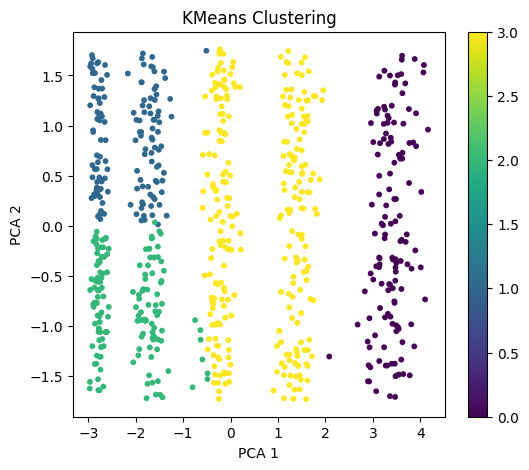

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', s=10)
plt.title("KMeans Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar()
plt.show()

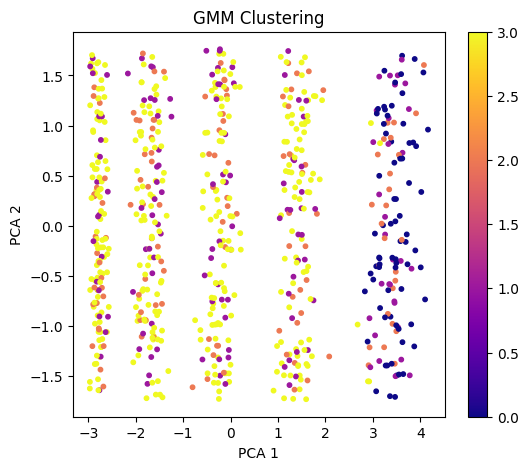

In [92]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, cmap='plasma', s=10)
plt.title("GMM Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar()
plt.show()

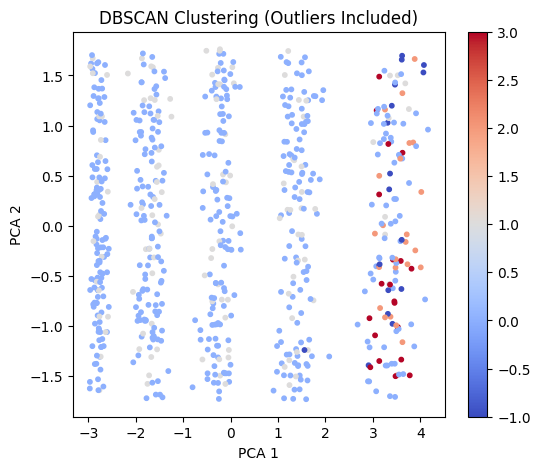

In [93]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, cmap='coolwarm', s=10)
plt.title("DBSCAN Clustering (Outliers Included)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar()
plt.show()

In [94]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

k_range = range(2, 11)

results = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_processed)
    
    sil = silhouette_score(X_processed, labels)
    dbi = davies_bouldin_score(X_processed, labels)
    
    results.append((k, sil, dbi))
    
    print(f"k={k} → Silhouette: {sil:.4f}, DB Index: {dbi:.4f}")

k=2 → Silhouette: 0.3974, DB Index: 0.9958
k=3 → Silhouette: 0.2475, DB Index: 1.6642
k=4 → Silhouette: 0.2017, DB Index: 1.5368
k=5 → Silhouette: 0.1911, DB Index: 1.8614
k=6 → Silhouette: 0.1802, DB Index: 1.8549
k=7 → Silhouette: 0.1868, DB Index: 1.7525
k=8 → Silhouette: 0.1846, DB Index: 1.6667
k=9 → Silhouette: 0.1850, DB Index: 1.6593
k=10 → Silhouette: 0.2015, DB Index: 1.6316


In [95]:
best_k = max(results, key=lambda x: x[1])  # berdasarkan silhouette
print("Best k:", best_k)

Best k: (2, 0.3973941719431729, 0.9958478941427765)


In [98]:
param_grid = {
    'init': ['k-means++', 'random'],
    'n_init': [10, 20],
    'max_iter': [300, 500]
}

best_score = -1
best_params = None

for init in param_grid['init']:
    for n_init in param_grid['n_init']:
        for max_iter in param_grid['max_iter']:
            
            kmeans = KMeans(
                n_clusters=best_k[0],
                init=init,
                n_init=n_init,
                max_iter=max_iter,
                random_state=42
            )
            
            labels = kmeans.fit_predict(X_processed)
            sil = silhouette_score(X_processed, labels)
            
            if sil > best_score:
                best_score = sil
                best_params = (init, n_init, max_iter)

print("Best Params:", best_params)
print("Best Silhouette:", best_score)

Best Params: ('k-means++', 10, 300)
Best Silhouette: 0.3973941719431729


In [99]:
kmeans_final = KMeans(
    n_clusters=best_k[0],
    init=best_params[0],
    n_init=best_params[1],
    max_iter=best_params[2],
    random_state=42
)

labels_final = kmeans_final.fit_predict(X_processed)

In [100]:
df['cluster'] = labels_final

In [101]:
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class,cluster
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4,0
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3,1
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2,1
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3,1
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3,1


In [102]:
df['cluster'].value_counts()

cluster
1    425
0    275
Name: count, dtype: int64